## Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DBD4117B90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DBD4294140>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

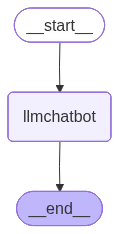

In [7]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
response=graph.invoke({"messages":"Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='32f4569e-485c-47b4-a656-99bf016b3dbc'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.027903476, 'completion_tokens_details': None, 'prompt_time': 0.00252255, 'prompt_tokens_details': None, 'queue_time': 0.005737304, 'total_time': 0.030426026}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1d5f-9d83-7061-8b66-a758c222b849-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [9]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [10]:
for event in graph.stream({"messages":"Hi How are you?"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings in the same way humans do, but I'm here to help answer any questions or provide information you might need. What's on your mind today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 40, 'total_tokens': 94, 'completion_time': 0.086579275, 'completion_tokens_details': None, 'prompt_time': 0.002447695, 'prompt_tokens_details': None, 'queue_time': 0.005591341, 'total_time': 0.08902697}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_8f8420ecd7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1d5f-9ea6-7041-828a-5b307f9d5ce4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 54, 'total_tokens': 94})]}}


In [11]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help you with any questions or tasks you may have. How can I assist you today?


## Chatbot With Tool

In [12]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'response_time': 1.63,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. By combining these technologies with a set of APIs and tools, LangGraph provides users with a versatile platform for developing AI solutions and workflows including chatbots, state graphs and other agent-based systems. **Nodes**: In LangGraph, nodes represent individual components or agents within an AI workflow. LangGraph uses enhanced decisio

In [13]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [14]:
tools=[tool,multiply]

In [15]:
llm_with_tool=llm.bind_tools(tools)

In [16]:
llm_with_tool

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DBD4117B90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DBD4294140>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input sho

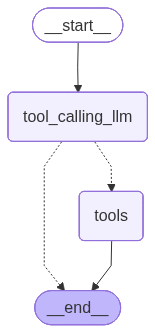

In [17]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [19]:
response

{'messages': [HumanMessage(content='What is the recent ai news', additional_kwargs={}, response_metadata={}, id='c022c89d-bc60-4644-bcfd-bba5957d3bc6'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'at3tqdbkz', 'function': {'arguments': '{"query":"recent AI news","search_depth":"advanced","start_date":"2024-01-01","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 1751, 'total_tokens': 1794, 'completion_time': 0.059629691, 'completion_tokens_details': None, 'prompt_time': 0.114300472, 'prompt_tokens_details': None, 'queue_time': 0.0054068, 'total_time': 0.173930163}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1d5f-a3f0-7e52-9620-702ace925961-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'sea

In [20]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/03/01/forget-deepseek-of-chinas-5-new-ai-models-ubs-prefers-this-one.html", "title": "Forget DeepSeek. China’s already released 5 new AI models and UBS prefers this one - CNBC", "score": 0.97112906, "published_date": "Sun, 01 Mar 2026 12:36:54 GMT", "content": "public in Hong Kong in January. Its recent GLM 5.0 model focuses on coding. Rival Chinese startup Moonshot, which released a popular Kimi 2.5 model in late January, is still privately held and has also focused more on coding and agentic-powered task completion, rather than audiovisual generation. 2025 global shock Anticipation of a new DeepSeek model climbed around the nine-day Lunar New Year holiday that ended Feb. 23. The Chinese startup\'s model release ahead of the same holiday last year shocked global markets with how advanced China\'s generative AI capabilities had become, despite U.S. chip

In [21]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (at3tqdbkz)
 Call ID: at3tqdbkz
  Args:
    query: recent AI news
    search_depth: advanced
    start_date: 2024-01-01
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/03/01/forget-deepseek-of-chinas-5-new-ai-models-ubs-prefers-this-one.html", "title": "Forget DeepSeek. China’s already released 5 new AI models and UBS prefers this one - CNBC", "score": 0.97112906, "published_date": "Sun, 01 Mar 2026 12:36:54 GMT", "content": "public in Hong Kong in January. Its recent GLM 5.0 model focuses on coding. Rival Chinese startup Moonshot, which released a popular Kimi 2.5 model 

In [22]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (5sx0r2857)
 Call ID: 5sx0r2857
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [23]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (0339d44va)
 Call ID: 0339d44va
  Args:
    query: AI news
    search_depth: ultra-fast
    time_range: day
    topic: news
  multiply (qkawws4vs)
 Call ID: qkawws4vs
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/hotels-shift-ai-spending-toward-earnings-focus-e3d670f2", "title": "Hotels Shift AI Spending Toward Earnings Focus - Let's Data Science", "score": 1.0, "published_date": "Mon, 23 Mar 2026 16:34:12 GMT", "content": "# Hotels Shift AI Spending Toward Earnings Focus | Let's Data Science. Image 1: LDS Logo LDS Let's Data Science

In [24]:
response=graph.invoke({"messages":"What is 5 multiplied by 2 and then multiply by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (anajwdv1p)
 Call ID: anajwdv1p
  Args:
    a: 5
    b: 2
  multiply (z8p0db499)
 Call ID: z8p0db499
  Args:
    a: 10
    b: 20
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

200


## ReAct Agent Architecture

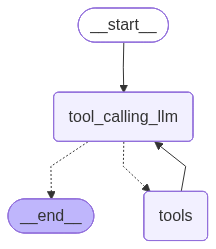

In [25]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (7cy3zsdpv)
 Call ID: 7cy3zsdpv
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (ghpfvz6cj)
 Call ID: ghpfvz6cj
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.computerworld.com/article/4148621/openai-to-double-workforce-highlights-growing-demand-for-enterprise-ai-talent.html", "title": "OpenAI to double workforce, highlights growing demand for enterprise AI talent - Computerworld", "score": 0.9805807, "published_date": "Mon, 23 Mar 2026 06:27:00 GMT", "content": "# OpenAI to double workforce, highlights growing dema

## Adding Memory In Agentic Graph

In [27]:
response=graph.invoke({"messages":"Hello my name is Ram"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ram
================================== Ai Message ==================================

Hello Ram, it's nice to meet you. Is there anything I can help you with today?


In [28]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have any information about your name. If you'd like to share it, I'd be happy to chat with you about it.


In [29]:
#We can overcome this. langgrpah has a property which can overcome this problm.

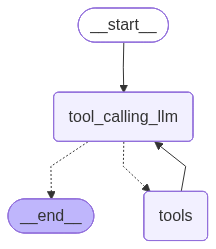

In [30]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Krish"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Krish', additional_kwargs={}, response_metadata={}, id='939698e1-2888-48de-9c30-c5d9b303ee2a'),
  AIMessage(content="Nice to meet you Krish. I'm happy to help you with any questions or tasks you may have. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1750, 'total_tokens': 1779, 'completion_time': 0.043903015, 'completion_tokens_details': None, 'prompt_time': 0.290991138, 'prompt_tokens_details': None, 'queue_time': 0.140466706, 'total_time': 0.334894153}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_dd2ecd7b1d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1d64-d629-7de1-8435-1b69dcd72872-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 29, 'total_tokens': 1779})]}

In [32]:
response['messages'][-1].content

"Nice to meet you Krish. I'm happy to help you with any questions or tasks you may have. How can I assist you today?"

In [33]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Krish.


In [34]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, I remember. Your name is Krish.


## Streaming

In [35]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [36]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

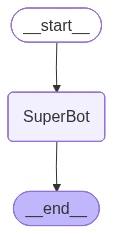

In [37]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [38]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='55b297ce-3c12-4b2a-9b20-ded61b63ce35'),
  AIMessage(content='Nice to meet you, Krish! Are you a fan of any particular team or player in cricket? Do you have a favorite cricket format - Test matches, One Day Internationals (ODIs), or Twenty20 (T20) cricket?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 45, 'total_tokens': 95, 'completion_time': 0.075622215, 'completion_tokens_details': None, 'prompt_time': 0.004655832, 'prompt_tokens_details': None, 'queue_time': 0.016097891, 'total_time': 0.080278047}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d317489708', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1d6c-a7e7-75a3-a814-52e5012170f8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_t

## Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

### *values : This streams the full state of the graph after each node is called.
*updates : This streams updates to the state of the graph after each node is called.

In [39]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'd love to chat with you about it. Are you a fan of a particular team, player, or format of the game (e.g. Test cricket, One-Day Internationals, or Twenty20)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 45, 'total_tokens': 103, 'completion_time': 0.081016312, 'completion_tokens_details': None, 'prompt_time': 0.002139108, 'prompt_tokens_details': None, 'queue_time': 0.170585033, 'total_time': 0.08315542}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1ed1-26e4-7ca3-ae91-f7a960f8229e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 58, 'total_tokens': 103})]}}


In [40]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='aa0e1081-afab-4efd-8433-7282730f0dcf'), AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'd love to chat with you about it. Are you a fan of a particular team, player, or format of the game (e.g. Test cricket, One-Day Internationals, or Twenty20)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 45, 'total_tokens': 103, 'completion_time': 0.081016312, 'completion_tokens_details': None, 'prompt_time': 0.002139108, 'prompt_tokens_details': None, 'queue_time': 0.170585033, 'total_time': 0.08315542}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1ed1-26e4-7ca3-ae91-f7a960f8229e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_t

In [41]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm happy to chat with you about it. Are you a fan of any particular team or player? Do you enjoy watching international matches or domestic leagues like the Indian Premier League (IPL)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 45, 'total_tokens': 99, 'completion_time': 0.070594688, 'completion_tokens_details': None, 'prompt_time': 0.005615775, 'prompt_tokens_details': None, 'queue_time': 0.008321046, 'total_time': 0.076210463}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1ed8-5769-7660-a027-b63796d85a09-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 54, 'total_tokens': 99})]}}


In [42]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='d7956d91-e999-4dca-97d0-75a7d56c5e1f'), AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm happy to chat with you about it. Are you a fan of any particular team or player? Do you enjoy watching international matches or domestic leagues like the Indian Premier League (IPL)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 45, 'total_tokens': 99, 'completion_time': 0.070594688, 'completion_tokens_details': None, 'prompt_time': 0.005615775, 'prompt_tokens_details': None, 'queue_time': 0.008321046, 'total_time': 0.076210463}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d1ed8-5769-7660-a027-b63796d85a09-0', tool_calls=[], invalid_tool_calls=[

In [43]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019d1edb-5472-7653-bdc0-fc133832d5f8', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='2d3bf994-1bc4-4bd7-afa9-ac514ca30b58')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019d1edb-548b-7bc2-b4fb-b0dfcd634aa9', 'metadata': {'thread_id': '5', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:6793fe29-0766-0f28-de55-f5fb7e214e77'}, 'parent_ids': ['019d1edb-5472-7653-bdc0-fc133832d5f8']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi My name is Krish and I like to pla